In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

print("TensorFlow version : ", tf.__version__)

TensorFlow version :  2.21.0


In [5]:
data = pd.read_csv("all_stocks_5yr.csv")
print("Dataset shape : ", data.shape)
data.head()

Dataset shape :  (619040, 7)


,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    619040 non-null  object 
 1   open    619029 non-null  float64
 2   high    619032 non-null  float64
 3   low     619032 non-null  float64
 4   close   619040 non-null  float64
 5   volume  619040 non-null  int64  
 6   Name    619040 non-null  object 
dtypes: float64(4), int64(1), object(2)
memory usage: 33.1+ MB


In [7]:
data.isnull().sum()

date       0
open      11
high       8
low        8
close      0
volume     0
Name       0
dtype: int64

In [8]:
data = data.dropna()
data.shape

(619029, 7)

In [10]:
data["date"] = pd.to_datetime(data["date"])
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 619029 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    619029 non-null  datetime64[ns]
 1   open    619029 non-null  float64       
 2   high    619029 non-null  float64       
 3   low     619029 non-null  float64       
 4   close   619029 non-null  float64       
 5   volume  619029 non-null  int64         
 6   Name    619029 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 37.8+ MB


In [11]:
# sort data by date

data = data.sort_values("date")
data.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.1200,14.630,14.75,8407500,AAL
508224,2013-02-08,81.22,81.9300,80.940,81.89,296853,SLG
506965,2013-02-08,78.24,79.0700,78.125,79.07,4632684,SLB
85755,2013-02-08,236.64,238.6924,235.750,238.16,552207,BLK
505706,2013-02-08,89.04,89.4800,88.910,89.16,554948,SJM


In [15]:
# perform EDA

print(data["Name"].unique())

['AAL' 'SLG' 'SLB' 'BLK' 'SJM' 'BLL' 'SIG' 'BMY' 'SHW' 'SEE' 'BRK.B'
 'SCHW' 'BSX' 'SCG' 'BWA' 'SBUX' 'BXP' 'SBAC' 'RTN' 'CAG' 'RSG' 'CAH'
 'RRC' 'CAT' 'ROST' 'ROP' 'BK' 'SNA' 'BIIB' 'SNI' 'AXP' 'SYMC' 'AYI' 'SYK'
 'AZO' 'SWK' 'A' 'SWKS' 'BAC' 'STZ' 'STX' 'BAX' 'CA' 'STT' 'STI' 'BBT'
 'SRE' 'SRCL' 'BBY' 'SPG' 'BDX' 'SPGI' 'BEN' 'SO' 'BF.B' 'SNPS' 'BA' 'ROK'
 'CBG' 'RMD' 'PRGO' 'CINF' 'PPL' 'CI' 'PPG' 'CLX' 'PNW' 'PNR' 'CL' 'PNC'
 'CMA' 'PM' 'CHTR' 'CMCSA' 'CME' 'PKI' 'PKG' 'CMG' 'PH' 'CMI' 'PHM' 'CMS'
 'PG' 'PGR' 'CNC' 'PFG' 'PLD' 'SYY' 'PRU' 'CHRW' 'CBOE' 'RL' 'CBS' 'RJF'
 'RHT' 'CB' 'RHI' 'CCI' 'RF' 'CCL' 'RE' 'CDNS' 'PSA' 'REG' 'CELG' 'RCL'
 'CERN' 'QCOM' 'PX' 'CF' 'PXD' 'PWR' 'CHD' 'PVH' 'CHK' 'PSX' 'REGN' 'CNP'
 'TAP' 'TDG' 'WMB' 'AES' 'WHR' 'AET' 'WFC' 'AFL' 'WEC' 'WDC' 'AGN' 'WBA'
 'AIG' 'WAT' 'AIV' 'V' 'AIZ' 'VZ' 'VTR' 'AJG' 'VRTX' 'AKAM' 'VRSN' 'ALB'
 'VRSK' 'ALGN' 'VNO' 'WMT' 'AEP' 'WM' 'AEE' 'ZION' 'AAP' 'ZBH' 'ABBV'
 'YUM' 'XYL' 'ABC' 'XRX' 'ABT' 'XRAY' 'ACN' 'XOM' 'VMC' 'A

In [16]:
print("Number of unique companies : ", data["Name"].unique())

Number of unique companies :  ['AAL' 'SLG' 'SLB' 'BLK' 'SJM' 'BLL' 'SIG' 'BMY' 'SHW' 'SEE' 'BRK.B'
 'SCHW' 'BSX' 'SCG' 'BWA' 'SBUX' 'BXP' 'SBAC' 'RTN' 'CAG' 'RSG' 'CAH'
 'RRC' 'CAT' 'ROST' 'ROP' 'BK' 'SNA' 'BIIB' 'SNI' 'AXP' 'SYMC' 'AYI' 'SYK'
 'AZO' 'SWK' 'A' 'SWKS' 'BAC' 'STZ' 'STX' 'BAX' 'CA' 'STT' 'STI' 'BBT'
 'SRE' 'SRCL' 'BBY' 'SPG' 'BDX' 'SPGI' 'BEN' 'SO' 'BF.B' 'SNPS' 'BA' 'ROK'
 'CBG' 'RMD' 'PRGO' 'CINF' 'PPL' 'CI' 'PPG' 'CLX' 'PNW' 'PNR' 'CL' 'PNC'
 'CMA' 'PM' 'CHTR' 'CMCSA' 'CME' 'PKI' 'PKG' 'CMG' 'PH' 'CMI' 'PHM' 'CMS'
 'PG' 'PGR' 'CNC' 'PFG' 'PLD' 'SYY' 'PRU' 'CHRW' 'CBOE' 'RL' 'CBS' 'RJF'
 'RHT' 'CB' 'RHI' 'CCI' 'RF' 'CCL' 'RE' 'CDNS' 'PSA' 'REG' 'CELG' 'RCL'
 'CERN' 'QCOM' 'PX' 'CF' 'PXD' 'PWR' 'CHD' 'PVH' 'CHK' 'PSX' 'REGN' 'CNP'
 'TAP' 'TDG' 'WMB' 'AES' 'WHR' 'AET' 'WFC' 'AFL' 'WEC' 'WDC' 'AGN' 'WBA'
 'AIG' 'WAT' 'AIV' 'V' 'AIZ' 'VZ' 'VTR' 'AJG' 'VRTX' 'AKAM' 'VRSN' 'ALB'
 'VRSK' 'ALGN' 'VNO' 'WMT' 'AEP' 'WM' 'AEE' 'ZION' 'AAP' 'ZBH' 'ABBV'
 'YUM' 'XYL' 'ABC' 'XRX' 'AB

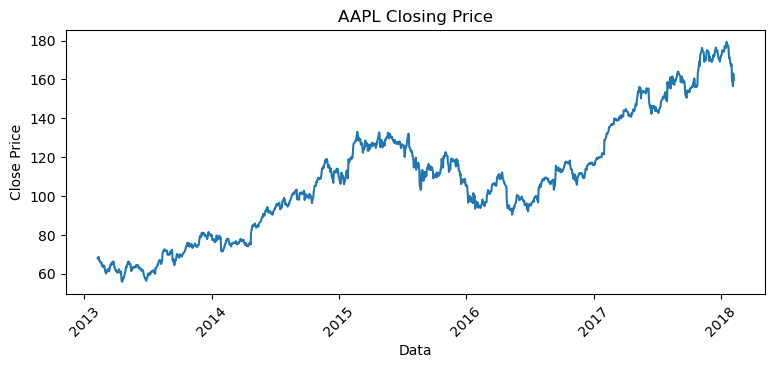

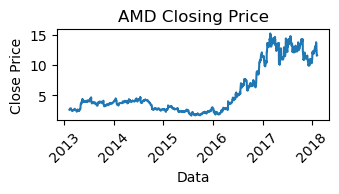

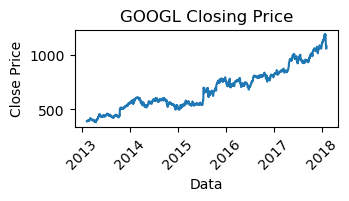

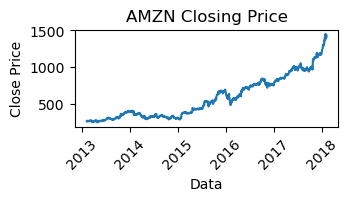

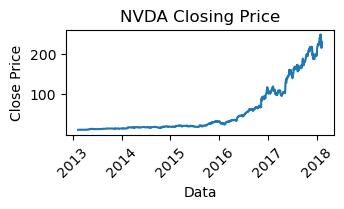

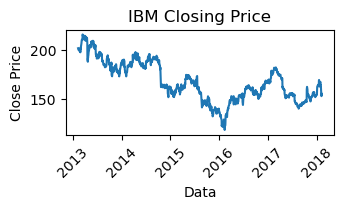

In [18]:
# visualixe some companies

companies = ["AAPL", "AMD", "GOOGL", "AMZN", "NVDA", "IBM"]
plt.figure(figsize = (15,10))

for index, company in enumerate(companies, 1):
    plt.subplot(3,2,index)
    company_data = data[data["Name"] == company]

    plt.plot(company_data["date"],
            company_data["close"]
    )

    plt.title(f"{company} Closing Price")

    plt.xlabel("Data")
    plt.ylabel("Close Price")
    plt.xticks(rotation = 45)

    plt.tight_layout()
    plt.show()

    # This helps us understand the general movement of different stocks.

In [19]:
# we will use the apple stock prices

apple = data[data["Name"] == "AAPL"].copy()
apple.head()

,date,open,high,low,close,volume,Name
1259,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL
1260,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL
1261,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL
1262,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL
1263,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL


In [20]:
print("Apple dataset shape : ", apple.shape)

Apple dataset shape :  (1259, 7)


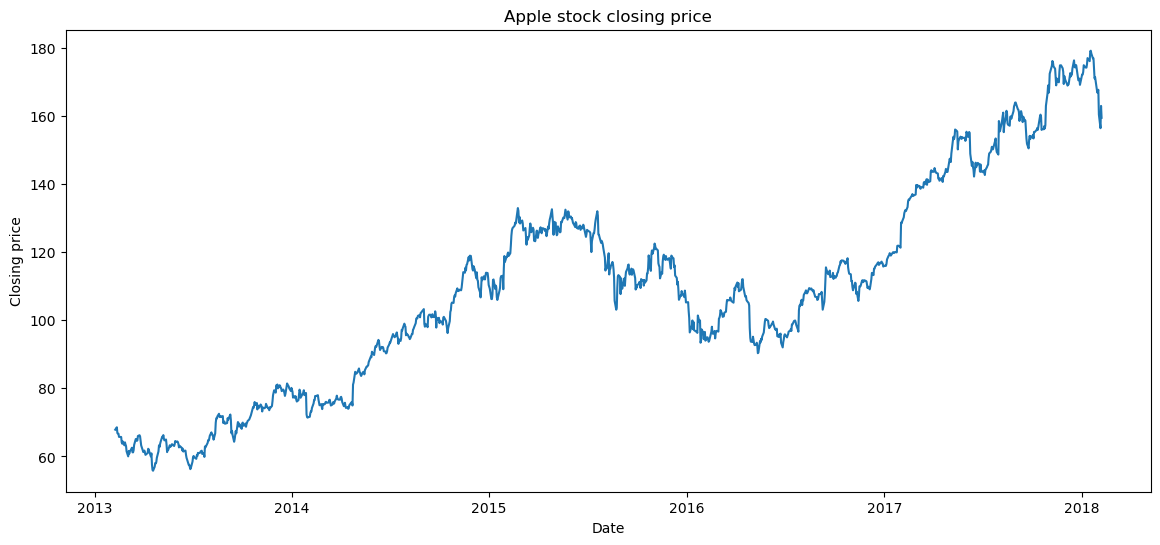

In [22]:
# plot apple closing price

plt.figure(figsize = (14,6))

plt.plot(
    apple["date"],
    apple["close"]
)

plt.title("Apple stock closing price");
plt.xlabel("Date")
plt.ylabel("Closing price")
plt.show()

In [23]:
# 9. Prepare the closing-price data

# We only need the close column for our basic LSTM model.

close_data = apple[["close"]]
dataset = close_data.values
print(dataset.shape)

(1259, 1)


In [24]:
# train and test data

training_size = int(len(dataset) * 0.80)

print("Total records : ", len(dataset))
print("Training records : ", training_size)
print("Testing records : ", len(dataset) - training_size)

Total records :  1259
Training records :  1007
Testing records :  252


In [26]:
# 11. Normalize the data
# LSTM networks generally train better when numerical values are scaled.
# We'll use MinMaxScaler to convert prices approximately into the range 0–1.

scaler = MinMaxScaler(feature_range= (0,1))
scaled_data = scaler.fit_transform(dataset)
print(scaled_data[:5])

[[0.0977103 ]
 [0.103438  ]
 [0.08951884]
 [0.08848863]
 [0.08800268]]


In [27]:
#12. Create training sequences
# This is the most important part.
# We'll use the previous 60 trading days to predict the next day's closing price.

train_data = scaled_data[:training_size]
x_train= []
y_train = []

for i in range(60, len(train_data)):

    # previous 60 days
    x_train.append(train_data[i-60:i,0])

    # next day's price
    y_train.append(train_data[i,0])

In [28]:
# Convert to NumPy arrays:
x_train = np.array(x_train)
y_train = np.array(y_train)

print("X train shape : ", x_train.shape)
print("Y train shape : ", y_train.shape)

X train shape :  (947, 60)
Y train shape :  (947,)


In [29]:
# 13. Reshape data for LSTM
# LSTM expects input in this format:
# (samples, time_steps, features)

#Meaning:
#samples → number of training sequences
#60 → previous 60 days
#1 → closing price feature


x_train = np.reshape(
    x_train, (x_train.shape[0], x_train.shape[1], 1)
)
print("Final X shape : ", x_train.shape)

Final X shape :  (947, 60, 1)


In [32]:
# Build the lstm model

model = keras.models.Sequential()

model.add(
    keras.layers.LSTM(
        units = 64,
        return_sequences = True,
        input_shape = (x_train.shape[1],1)
    )
)

model.add(
    keras.layers.LSTM(
        units = 64,
        return_sequences = False
    )
)

model.add(
    keras.layers.Dense(32)
)

model.add(
    keras.layers.Dropout(0.5)
)

model.add(
    keras.layers.Dense(1)
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 52,033 (203.25 KB)

 Trainable params: 52,033 (203.25 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# compile the model 

model.compile(
    optimizer = "adam",
    loss = "mean_squared_error"
)

In [34]:
# train the model

history = model.fit(
    x_train, y_train, epochs = 20, batch_size = 32,
    validation_split = 0.1,
    verbose = 1
)

Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - loss: 0.0193 - val_loss: 0.0010
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0076 - val_loss: 0.0028
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0060 - val_loss: 0.0010
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0055 - val_loss: 0.0014
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0057 - val_loss: 0.0014
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0050 - val_loss: 0.0019
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0045 - val_loss: 0.0016
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0053 - val_loss: 0.0023
Epoch 9/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0042 - val_loss: 5.8324e-04
Epoch 10/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0043 - val_loss: 4.5486e-04
Epoch 11/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0040 - val_loss: 0.0010
Epoch 12/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - l

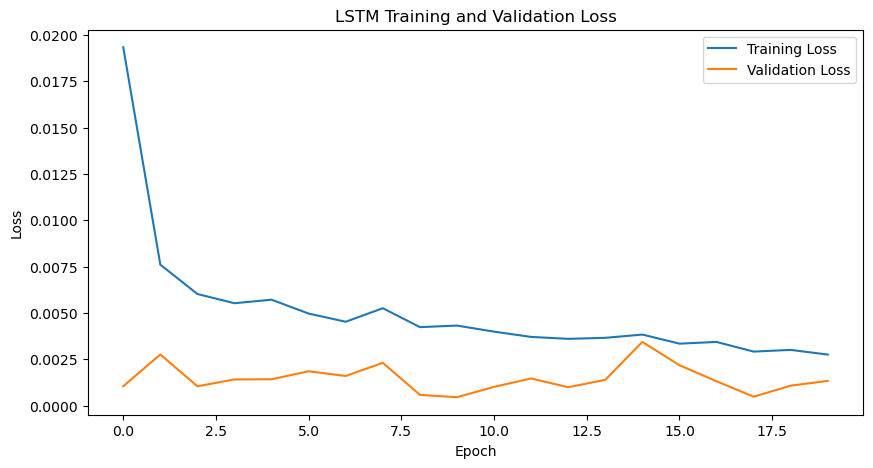

In [36]:
# plot training loss

plt.figure(figsize = (10,5))
plt.plot(
    history.history["loss"],
    label = "Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label = "Validation Loss"
)

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [37]:
# prepare testing data 

test_data = scaled_data[training_size - 60:]

x_test = []
y_test = dataset[training_size:]

for i in range(60, len(test_data)):
    x_test.append(
        test_data[i-60:i,0]
    )
x_test = np.array(x_test)
x_test = np.reshape(
    x_test,
    (x_test.shape[0], x_test.shape[1],1)
)

print("X test shape : ", x_test.shape)
print("Y test shape : ", y_test.shape)

X test shape :  (252, 60, 1)
Y test shape :  (252, 1)


In [49]:
# make predictions

predictions = model.predict(x_test)

# Currently predictions are scaled between 0 and 1.

# Convert them back to actual stock prices:

predictions = scaler.inverse_transform(predictions)
print(predictions[:10])

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
[[122.65105 ]
 [123.79878 ]
 [124.84545 ]
 [125.70738 ]
 [126.47663 ]
 [127.260864]
 [128.01654 ]
 [128.66699 ]
 [129.22298 ]
 [129.74963 ]]


In [50]:
# Calculate MSE and RMSE

mse = mean_squared_error(
    y_test,
    predictions
)

rmse= np.sqrt(mse)

mae = mean_absolute_error(
    y_test,
    predictions
)

print("Mean Squared Error : ", mse)
print("Root Mean Squared Error : ", rmse)
print("Mean Absolute Error : ", mae)

# Don't call RMSE an "accuracy percentage".

# For regression problems like stock-price prediction, 
# RMSE/MAE are more appropriate evaluation metrics than classification accuracy.

Mean Squared Error :  94.49407031510253
Root Mean Squared Error :  9.720806052745962
Mean Absolute Error :  9.112070905897351


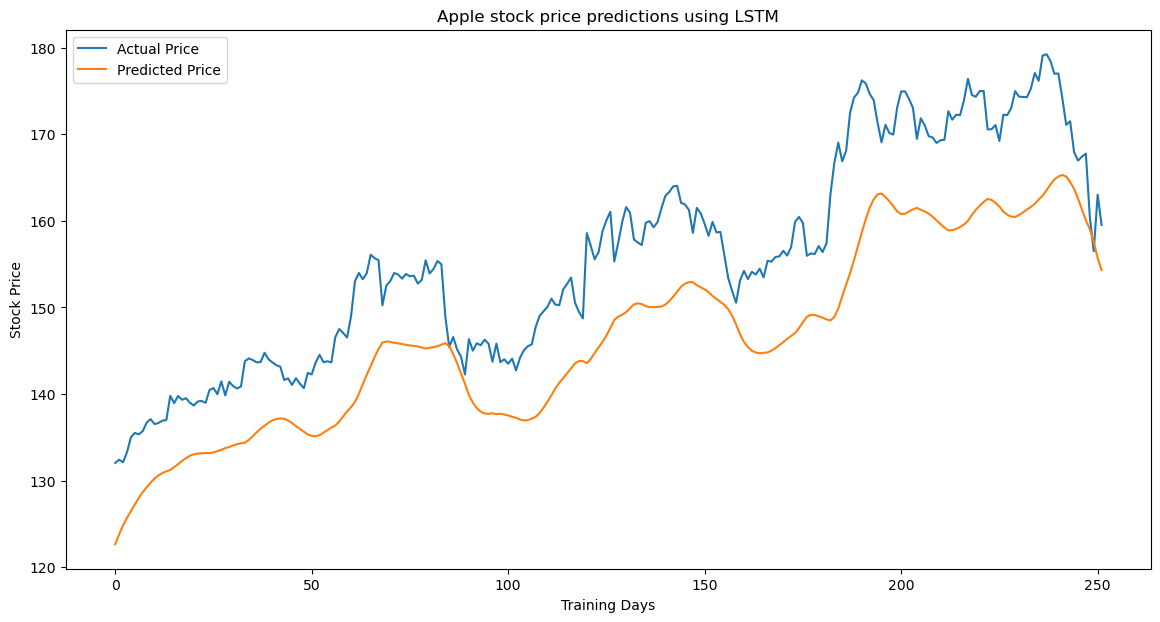

In [51]:
# compare actual vs predicted prices

plt.figure(figsize = (14,7))

plt.plot(
    y_test,
    label = "Actual Price"
)

plt.plot(
    predictions,
    label = "Predicted Price"
)

plt.title("Apple stock price predictions using LSTM")
plt.xlabel("Training Days")
plt.ylabel("Stock Price")

plt.legend()
plt.show()

In [61]:
# better visualization with actual dates

test_dates = apple["date"].iloc[training_size:].values

results = pd.DataFrame({
    "Date" : test_dates,
    "Actual" : y_test.flatten(),
    "Predicted" : predictions.flatten()
})
results.head()

,Date,Actual,Predicted
0,2017-02-08,132.04,122.651047
1,2017-02-09,132.42,123.798782
2,2017-02-10,132.12,124.845451
3,2017-02-13,133.29,125.707382
4,2017-02-14,135.02,126.476631


In [62]:

print(results.head())
print(results.columns)

        Date  Actual   Predicted
0 2017-02-08  132.04  122.651047
1 2017-02-09  132.42  123.798782
2 2017-02-10  132.12  124.845451
3 2017-02-13  133.29  125.707382
4 2017-02-14  135.02  126.476631
Index(['Date', 'Actual', 'Predicted'], dtype='object')


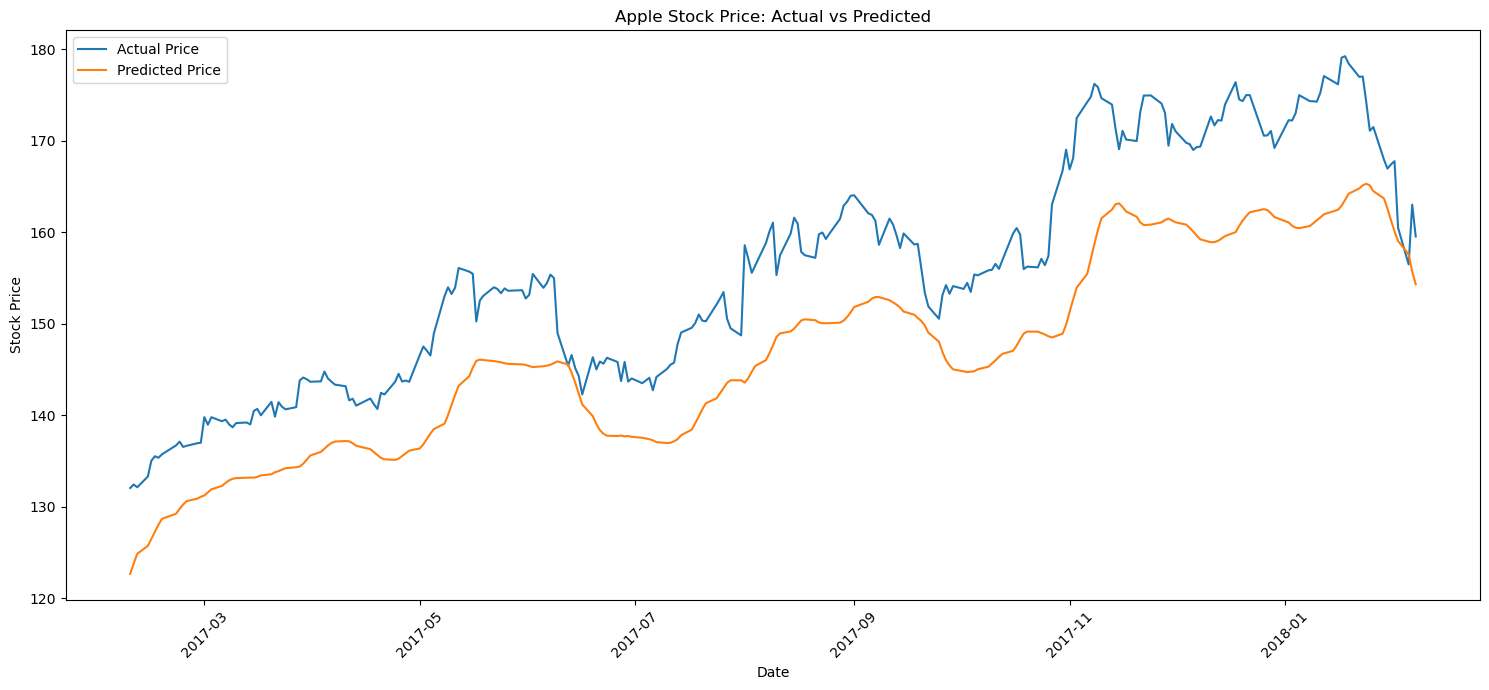

In [65]:
plt.figure(figsize=(15, 7))

plt.plot(
    results["Date"],
    results["Actual"],
    label="Actual Price"
)

plt.plot(
    results["Date"],
    results["Predicted"],
    label="Predicted Price"
)

plt.title("Apple Stock Price: Actual vs Predicted")

plt.xlabel("Date")
plt.ylabel("Stock Price")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [66]:
# save the trained model

model.save("apple_stock_lstm.keras")

In [67]:
# save the sacler 
import joblib

joblib.dump(
    scaler,
    "stock_scaler.pkl"
)

['stock_scaler.pkl']